In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openquake.commonlib.datastore import read


In [2]:
!oq engine --lrc

job_id |     status |          start_time |         description
     1 |   complete | 2024-11-03 12:06:15.308445 | Scenario Risk Demo (Catania Tsunami) using hysea simulation no aggregation
     2 |   complete | 2024-11-03 12:06:35.087976 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 892 no aggregation
     3 |   complete | 2024-11-03 12:06:54.806854 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 1658 no aggregation
     4 |   complete | 2024-11-03 12:07:16.469549 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 3454 no aggregation
     5 |   complete | 2024-11-03 12:12:18.075475 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 7071 no aggregation
     6 |   complete | 2024-11-03 13:17:53.362380 | Scenario Risk Demo (Catania Tsunami) using hysea simulation with foglio aggregation
     7 |   complete | 2024-11-03 13:19:15.386250 | Scenario Risk Demo (C

In [3]:
dstore = read(21)
list(dstore)


['agg_keys',
 'agg_values',
 'assetcol',
 'avg_losses-rlzs',
 'crm',
 'discarded',
 'events',
 'exposure',
 'full_lt',
 'gmf_data',
 'oqparam',
 'performance_data',
 'risk_by_event',
 'rupgeoms',
 'ruptures',
 'sitecol',
 'task_info',
 'task_sent',
 'taxmap',
 'weights']

In [8]:
dstore.read_df('risk_by_event').head()
# temp = dstore.read_df('risk_by_event')
# temp = temp[temp['agg_id'] == 3]

# dstore.close()

,event_id,agg_id,loss_id,variance,loss
0,53433,2,3,0.0,3.868647e+06
1,53434,2,3,0.0,8.035771e+05
2,53435,2,3,0.0,2.219740e+04
3,53436,2,3,0.0,4.492630e+06
4,53437,2,3,0.0,2.141098e+06


In [13]:
file = '/home/naveen.raguramalinga/oqdata/calc_21.hdf5'

with h5py.File(file, 'r') as f:
    agg_keys = f['agg_keys'][:]
    f.close()

# remove b in string values in the np array agg_keys,ex b'19089001000000292200' to 19089001000000292200
agg_keys = np.array([x.decode('utf-8') for x in agg_keys])

# convert the np array to a pandas dataframe
agg_keys = pd.DataFrame(agg_keys, columns=['const_id'])
agg_keys['agg_id'] = agg_keys.index
num_keys = len(agg_keys)

#save IDAG and agg_id key to a csv file
agg_keys.to_csv('0_const_keys.csv', index=False)

In [14]:
event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index

run_name = ['true','892','1658','3454','7071']

for i,job_id in enumerate([21,22,23,24,25]):
    print(f'Job {job_id} for {run_name[i]}')
    # Load the results
    dstore = read(job_id)

    # Extract the data
    data_event = dstore.read_df('risk_by_event')

    #remove rows with agg_id with total from agg_keys
    # direct_event_loss = data_event[data_event['agg_id'] == num_keys]
    data_event = data_event[data_event['agg_id'] != num_keys]

    #Join the data with the agg_keys
    data_event = data_event.join(agg_keys.set_index('agg_id'), on='agg_id')
    data_event = data_event.sort_values(by='event_id')

    #aggregate the data based on event_id
    event_loss = data_event.groupby('event_id')['loss'].sum()
        
    #remove events less than 500 loss value
    # event_loss = event_loss[event_loss > 500]

    #remove from data_event the events with loss less than 500
    # data_event = data_event[data_event['event_id'].isin(event_loss.index)]

    #number of events
    print('Number of events:', len(event_loss))

    #save the data to a csv file
    event_loss.to_csv(f'1_event_const_loss_{run_name[i]}.csv', index=True)
    data_event.to_csv(f'2_const_event_loss_{run_name[i]}.csv', index=True)

    #append event_loss to event_info
    event_info = event_info.join(event_loss, on='event_id', rsuffix=f'_{run_name[i]}')

#rename column loss to loss_true
event_info.rename(columns={'loss':'loss_true'}, inplace=True)

#set missing values to 0
event_info[f'loss_true'] = event_info[f'loss_true'].fillna(0)
event_info[f'loss_892'] = event_info[f'loss_892'].fillna(0)
event_info[f'loss_1658'] = event_info[f'loss_1658'].fillna(0)
event_info[f'loss_3454'] = event_info[f'loss_3454'].fillna(0)
event_info[f'loss_7071'] = event_info[f'loss_7071'].fillna(0)

#save the data to a csv file
event_info.to_csv('3_event_info_const_loss.csv', index=False)


Job 21 for true
Number of events: 43895
Job 22 for 892
Number of events: 53519
Job 23 for 1658
Number of events: 53543
Job 24 for 3454
Number of events: 53475
Job 25 for 7071
Number of events: 53386


In [15]:
def get_loss_pml(loss,rate,threshold,PoE):

    total_value = 28491684200

    #filter events based on threshold of 500
    print('Number of events before filtering:', len(loss))
    rate = rate[loss>threshold]
    loss = loss[loss>threshold]
    print('Number of events after filtering:', len(loss))

    #reset index
    rate = rate.reset_index(drop=True)
    loss = loss.reset_index(drop=True)

    #sort descending
    idx = np.argsort(loss)[::-1]
    sorted_loss = loss[idx]
    sorted_rate = rate[idx]  
    
    #Event loss table
    ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
    ELT['weighted_loss'] = sorted_loss*sorted_rate
    ELT['cumulative_probability'] = ELT['rate'].cumsum()

    AAL = np.sum(ELT['weighted_loss'])
    print('AAL:',AAL,'\n')

    PML = np.zeros(len(PoE))
    PML_ratio = np.zeros(len(PoE))
    #find the event loss for each RP
    for i,probability_level in enumerate(PoE):
        PML[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()
        if PML[i] == np.nan:
            PML_ratio[i] = 0
        else:
            PML_ratio[i] = PML[i]/total_value
    return PML,PML_ratio,ELT

Number of events before filtering: 53550
Number of events after filtering: 41018
AAL: 19517.399679661758 

Number of events before filtering: 53550
Number of events after filtering: 53112
AAL: 13889.922110437152 

Number of events before filtering: 53550
Number of events after filtering: 53368
AAL: 17714.976651971847 

Number of events before filtering: 53550
Number of events after filtering: 53197
AAL: 15044.888702436354 

Number of events before filtering: 53550
Number of events after filtering: 45626
AAL: 15604.38106351551 



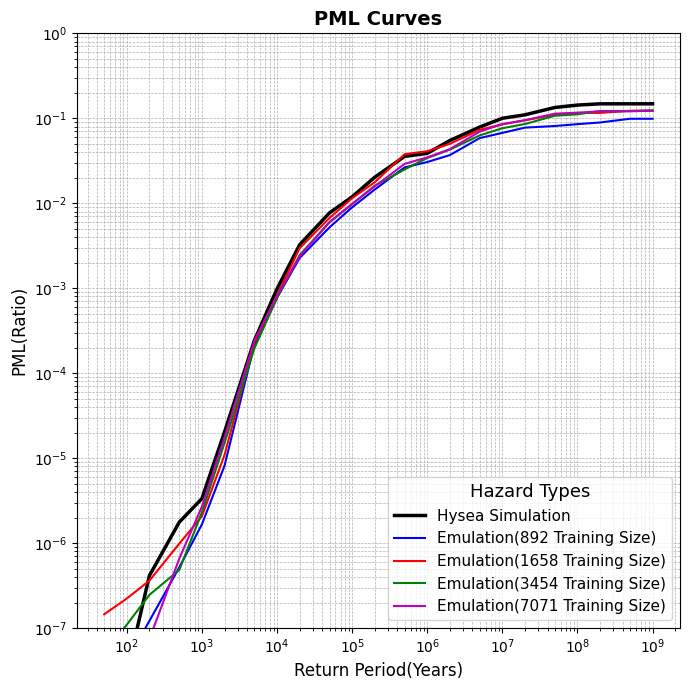

In [16]:
#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10, 20, 50,
      100, 200, 500, 
      1000, 2000, 5000,
      10000, 20000, 50000, 
      100000, 200000, 500000, 
      1000000, 2000000, 5000000, 
      10000000, 20000000, 50000000, 
      100000000, 200000000, 500000000, 1000000000]

PoE = [1/rp for rp in RP]

min_loss = 500

PML_true = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],min_loss,PoE)[1]
PML_892 = get_loss_pml(event_info['loss_892'],event_info['mean_prob'],min_loss,PoE)[1]
PML_1658 = get_loss_pml(event_info['loss_1658'],event_info['mean_prob'],min_loss,PoE)[1]
PML_3454 = get_loss_pml(event_info['loss_3454'],event_info['mean_prob'],min_loss,PoE)[1]
PML_7071 = get_loss_pml(event_info['loss_7071'],event_info['mean_prob'],min_loss,PoE)[1]


#plot
fig, ax = plt.subplots(figsize=(7, 7))

# Use a professional color palette
colors = ['k', 'b', 'r', 'g', 'm']

ax.plot(RP, PML_true, label='Hysea Simulation', color=colors[0], linewidth=2.5)
ax.plot(RP, PML_892, label='Emulation(892 Training Size)', color=colors[1], linewidth=1.5)
ax.plot(RP, PML_1658, label='Emulation(1658 Training Size)', color=colors[2], linewidth=1.5)
ax.plot(RP, PML_3454, label='Emulation(3454 Training Size)', color=colors[3], linewidth=1.5)
ax.plot(RP, PML_7071, label='Emulation(7071 Training Size)', color=colors[4], linewidth=1.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Return Period(Years)', fontsize=12)
ax.set_ylabel('PML(Ratio)', fontsize=12)
ax.set_title('PML Curves', fontsize=14, fontweight='bold')
ax.set_ylim(1e-7, 1e0)

# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend
ax.legend(title='Hazard Types', title_fontsize='13', fontsize='11')

# Customize ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Show plot
plt.tight_layout()
plt.show()

In [17]:
# Calculate at foglio level for the true and emulated hazards



